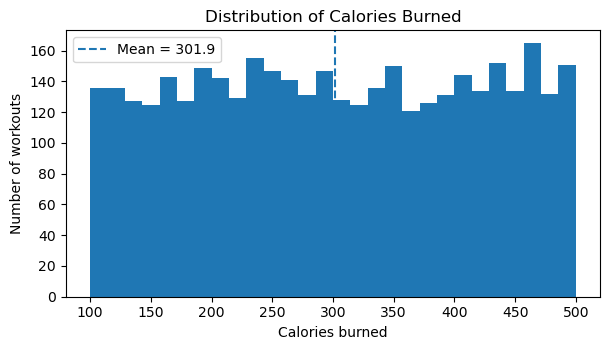

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path(".")
fig_dir = base / "figures"
fig_dir.mkdir(exist_ok=True)

df = pd.read_csv("exercise_dataset.csv")
summary = json.loads(Path("computed_summary.json").read_text()) if Path("computed_summary.json").exists() else None

def savefig(name):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{name}.pdf", bbox_inches="tight")
    plt.savefig(fig_dir / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()

# 1. In this first, we will graph to measure distribution of calories
fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.hist(df["Calories Burn"], bins=28)
ax.axvline(df["Calories Burn"].mean(), linestyle="--", linewidth=1.5, label=f"Mean = {df['Calories Burn'].mean():.1f}")
ax.set_title("Distribution of Calories Burned")
ax.set_xlabel("Calories burned")
ax.set_ylabel("Number of workouts")
ax.legend()
savefig("jupyter_01_calorie_distribution")


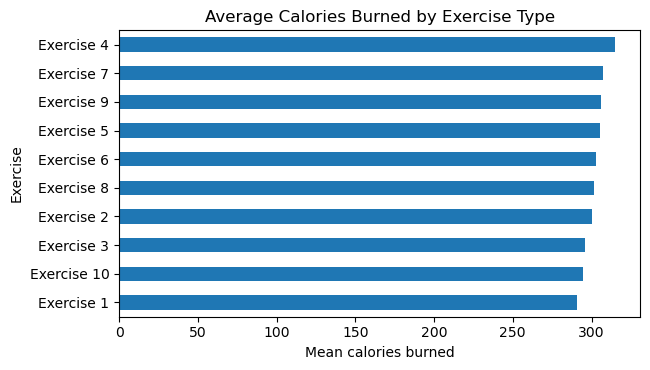

In [2]:
# 2. Average calories by exercise
exercise_means = df.groupby("Exercise")["Calories Burn"].mean().sort_values()
fig, ax = plt.subplots(figsize=(6.6, 3.8))
exercise_means.plot(kind="barh", ax=ax)
ax.set_title("Average Calories Burned by Exercise Type")
ax.set_xlabel("Mean calories burned")
ax.set_ylabel("Exercise")
savefig("jupyter_02_exercise_means")

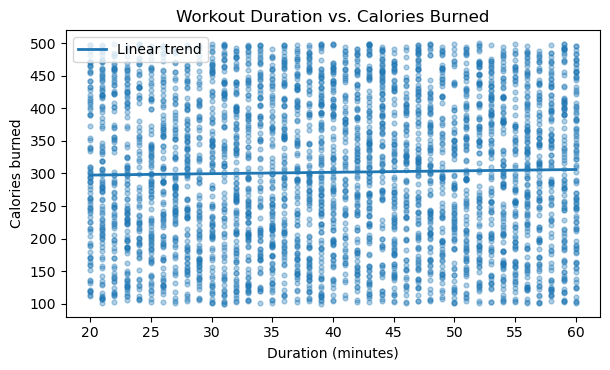

In [3]:
# 3. Time Duration vs. Calories
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.scatter(df["Duration"], df["Calories Burn"], alpha=0.35, s=12)
coef = np.polyfit(df["Duration"], df["Calories Burn"], 1)
x_line = np.linspace(df["Duration"].min(), df["Duration"].max(), 100)
ax.plot(x_line, coef[0] * x_line + coef[1], linewidth=2, label="Linear trend")
ax.set_title("Workout Duration vs. Calories Burned")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Calories burned")
ax.legend()
savefig("jupyter_03_duration_vs_calories")

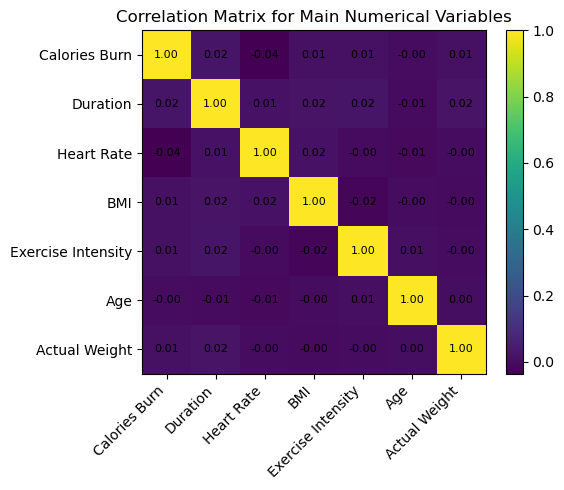

In [4]:
# 4. Correlation Heatmap
corr_cols = ["Calories Burn", "Duration", "Heart Rate", "BMI", "Exercise Intensity", "Age", "Actual Weight"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(6.3, 5.0))
im = ax.imshow(corr.values)
ax.set_title("Correlation Matrix for Main Numerical Variables")
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
savefig("jupyter_04_correlation_heatmap")

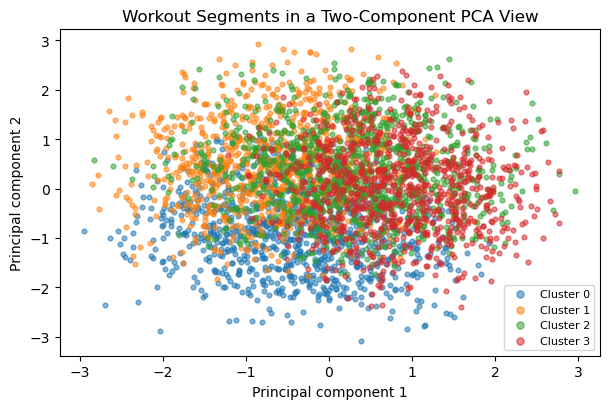

In [5]:
# 5. NumPy K-Means and PCA view
cluster_features = ["Calories Burn", "Actual Weight", "Age", "Duration", "Heart Rate", "BMI", "Exercise Intensity"]
X = df[cluster_features].to_numpy(dtype=float)
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
rng = np.random.default_rng(42)
k = 4
centers = X_scaled[rng.choice(len(X_scaled), size=k, replace=False)]
for _ in range(60):
    distances = ((X_scaled[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    labels = distances.argmin(axis=1)
    new_centers = np.array([X_scaled[labels == c].mean(axis=0) if np.any(labels == c) else centers[c] for c in range(k)])
    if np.allclose(new_centers, centers):
        break
    centers = new_centers

X_centered = X_scaled - X_scaled.mean(axis=0)
_, _, vt = np.linalg.svd(X_centered, full_matrices=False)
pca2 = X_centered @ vt[:2].T
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for c in range(k):
    ax.scatter(pca2[labels == c, 0], pca2[labels == c, 1], s=12, alpha=0.55, label=f"Cluster {c}")
ax.set_title("Workout Segments in a Two-Component PCA View")
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
ax.legend(markerscale=1.5, fontsize=8)
savefig("jupyter_06_workout_clusters_pca")

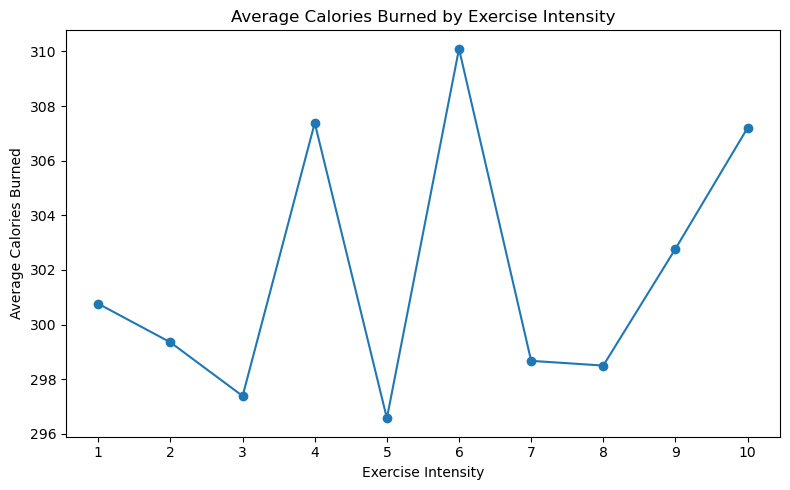

In [6]:
# Determining Calories by Exercise Intensity

avg_cal_by_intensity = df.groupby("Exercise Intensity")["Calories Burn"].mean().sort_index()

plt.figure(figsize=(8, 5))
plt.plot(avg_cal_by_intensity.index, avg_cal_by_intensity.values, marker="o")
plt.title("Average Calories Burned by Exercise Intensity")
plt.xlabel("Exercise Intensity")
plt.ylabel("Average Calories Burned")
plt.xticks(avg_cal_by_intensity.index)
plt.tight_layout()
plt.show()